# Ensemble Learning, Model Optimization & Real-World ML Pipeline

## Objective

To apply ensemble learning techniques for binary classification and compare their performance with traditional machine learning models.

The main objectives are:

- Implement Random Forest and Gradient Boosting classifiers.
- Compare different machine learning models using evaluation metrics.
- Apply cross-validation to measure model reliability.
- Perform hyperparameter tuning using GridSearchCV.
- Analyze feature importance for model interpretation.
- Build a complete end-to-end machine learning workflow.
- Select the best-performing model based on evaluation results.

## Libraries Used
- Random Forest
- Gradient Boosting
- GridSearchCV
- Cross-Validation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


## Load the Breast Cancer Dataset


In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)


In [4]:
df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Dataset Exploration


In [5]:
print("Dataset Shape:", df.shape)
print("\nTarget Classes:")
print(df["target"].value_counts())

print("\nDataset Information:")
print(df.info())

Dataset Shape: (569, 31)

Target Classes:
target
1    357
0    212
Name: count, dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error    

In [6]:
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Class Distribution

In [7]:
print("Class Distribution:")
print(df["target"].value_counts())

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


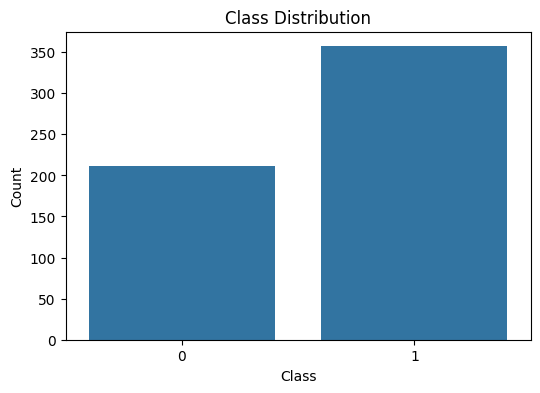

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df["target"])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


## Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## Logistic Regression

In [12]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [13]:
y_pred = log_model.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


## Classification Metrics

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112


## Confusion Matrix

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


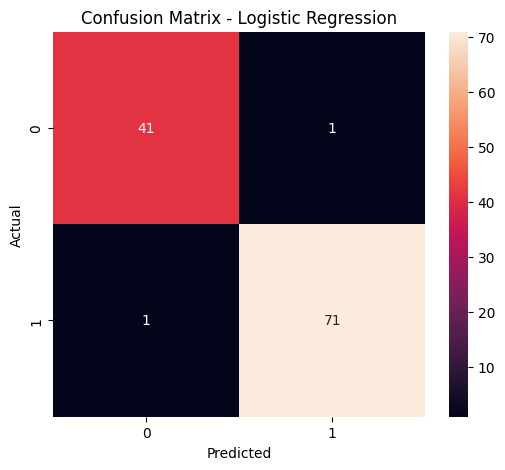

In [16]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## ROC Curve and AUC

In [18]:
y_probability = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

auc_score = roc_auc_score(y_test, y_probability)

print("AUC Score:", auc_score)

AUC Score: 0.9953703703703703


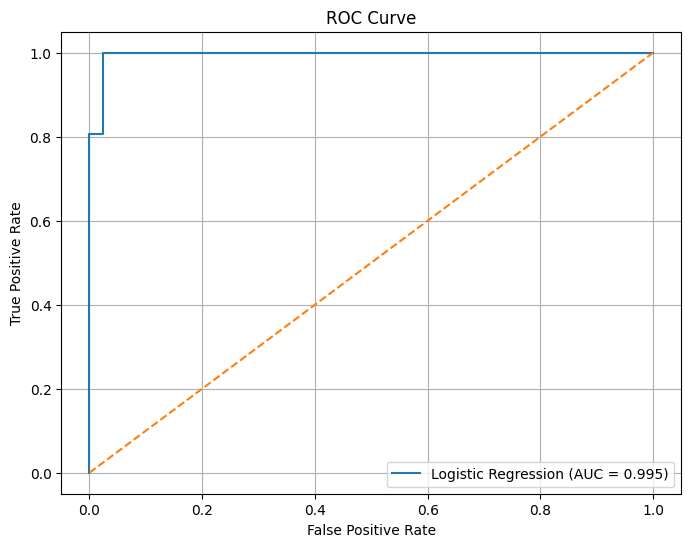

In [19]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

## Cross-Validation

In [20]:
cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Average CV F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.97391304 0.98214286 0.97435897 1.         0.99130435]
Average CV F1 Score: 0.9843438445612358


## Handling Imbalanced Data using Class Weights

In [21]:
weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

weighted_model.fit(X_train_scaled, y_train)

weighted_pred = weighted_model.predict(X_test_scaled)

print("Balanced Logistic Regression")
print("Accuracy:", accuracy_score(y_test, weighted_pred))
print("Precision:", precision_score(y_test, weighted_pred))
print("Recall:", recall_score(y_test, weighted_pred))
print("F1 Score:", f1_score(y_test, weighted_pred))

Balanced Logistic Regression
Accuracy: 0.956140350877193
Precision: 0.9855072463768116
Recall: 0.9444444444444444
F1 Score: 0.9645390070921985


## Decision Tree Classifier

In [22]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Classifier trained successfully!")


Decision Tree Classifier trained successfully!


In [23]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1 Score:", dt_f1)

Decision Tree Accuracy: 0.9122807017543859
Decision Tree Precision: 0.9558823529411765
Decision Tree Recall: 0.9027777777777778
Decision Tree F1 Score: 0.9285714285714286


## Random Forest Classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Results
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


## Gradient Boosting Classifier

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

Gradient Boosting Results
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231


## Cross-Validation Comparison of Models

In [30]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

cv_results = {}

for name, model in models.items():

    if name == "Logistic Regression":
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="f1"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="f1"
        )

    cv_results[name] = scores.mean()

    print(name)
    print("CV F1 Scores:", scores)
    print("Average CV F1:", scores.mean())
    print()

Logistic Regression
CV F1 Scores: [0.97391304 0.98214286 0.97435897 1.         0.99130435]
Average CV F1: 0.9843438445612358

Decision Tree
CV F1 Scores: [0.92857143 0.91891892 0.92307692 0.9137931  0.95652174]
Average CV F1: 0.9281764226291962

Random Forest
CV F1 Scores: [0.97391304 0.99130435 0.94017094 0.94736842 0.96428571]
Average CV F1: 0.9634084933627267

Gradient Boosting
CV F1 Scores: [0.97345133 0.97345133 0.94827586 0.95652174 0.97345133]
Average CV F1: 0.9650303167000571



## Cross-Validation Performance Comparison

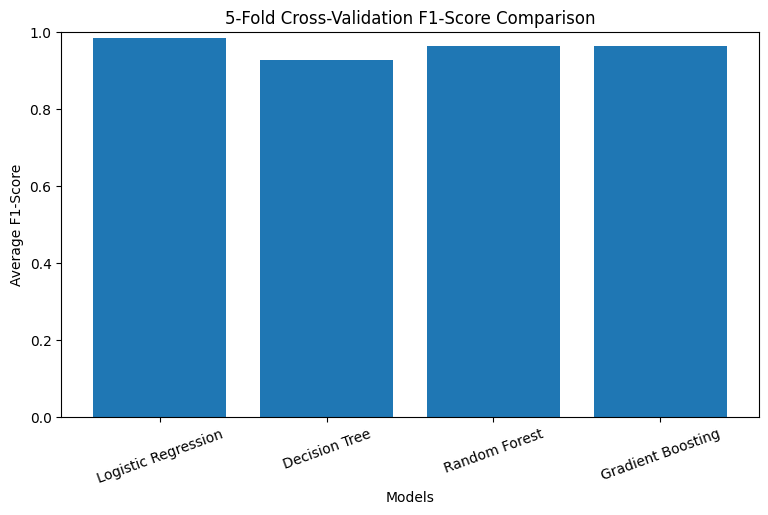

In [31]:
plt.figure(figsize=(9, 5))

plt.bar(
    cv_results.keys(),
    cv_results.values()
)

plt.title("5-Fold Cross-Validation F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("Average F1-Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

## Hyperparameter Tuning using GridSearchCV

In [25]:
params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5}
Best CV F1 Score: 0.9517702618506719


In [26]:
tuned_pred = best_tree.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Decision Tree Accuracy:", tuned_accuracy)
print("Tuned Decision Tree Precision:", tuned_precision)
print("Tuned Decision Tree Recall:", tuned_recall)
print("Tuned Decision Tree F1 Score:", tuned_f1)

Tuned Decision Tree Accuracy: 0.9210526315789473
Tuned Decision Tree Precision: 0.9565217391304348
Tuned Decision Tree Recall: 0.9166666666666666
Tuned Decision Tree F1 Score: 0.9361702127659575


## Random Forest Hyperparameter Tuning

In [32]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1 Score:
0.9684436877471334


## Tuned Random Forest Evaluation

In [33]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)

print("Tuned Random Forest Results")
print("Accuracy:", best_rf_accuracy)
print("Precision:", best_rf_precision)
print("Recall:", best_rf_recall)
print("F1 Score:", best_rf_f1)

Tuned Random Forest Results
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


## Random Forest Feature Importance

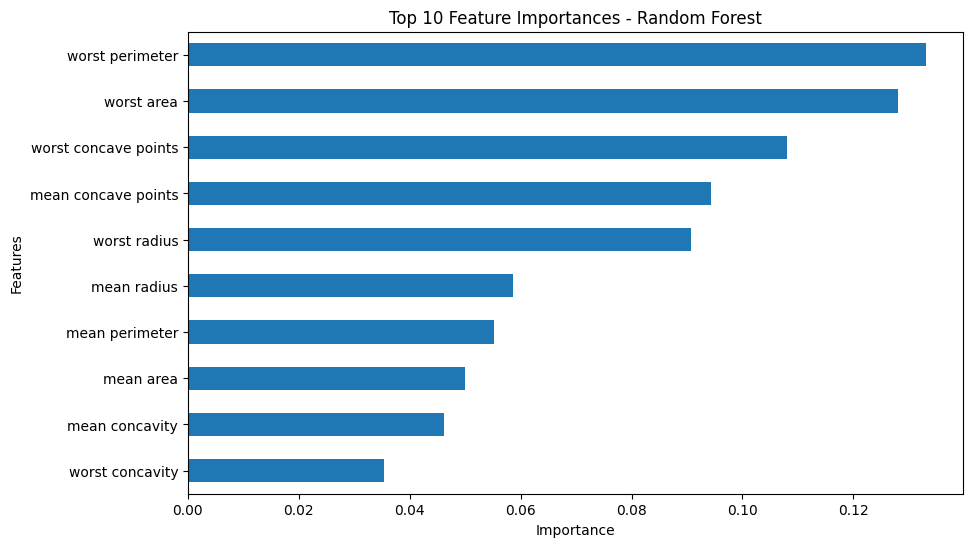

In [34]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=data.feature_names
)

top_features = importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

## Model Comparison

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        accuracy,
        accuracy_score(y_test, weighted_pred),
        dt_accuracy,
        tuned_accuracy,
        rf_accuracy,
        gb_accuracy,
        best_rf_accuracy
    ],

    "Precision": [
        precision,
        precision_score(y_test, weighted_pred),
        dt_precision,
        tuned_precision,
        rf_precision,
        gb_precision,
        best_rf_precision
    ],

    "Recall": [
        recall,
        recall_score(y_test, weighted_pred),
        dt_recall,
        tuned_recall,
        rf_recall,
        gb_recall,
        best_rf_recall
    ],

    "F1 Score": [
        f1,
        f1_score(y_test, weighted_pred),
        dt_f1,
        tuned_f1,
        rf_f1,
        gb_f1,
        best_rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539
2,Decision Tree,0.912281,0.955882,0.902778,0.928571
3,Tuned Decision Tree,0.921053,0.956522,0.916667,0.936170
4,Random Forest,0.956140,0.958904,0.972222,0.965517
5,Gradient Boosting,0.956140,0.946667,0.986111,0.965986
6,Tuned Random Forest,0.956140,0.958904,0.972222,0.965517


## Model Performance Comparison

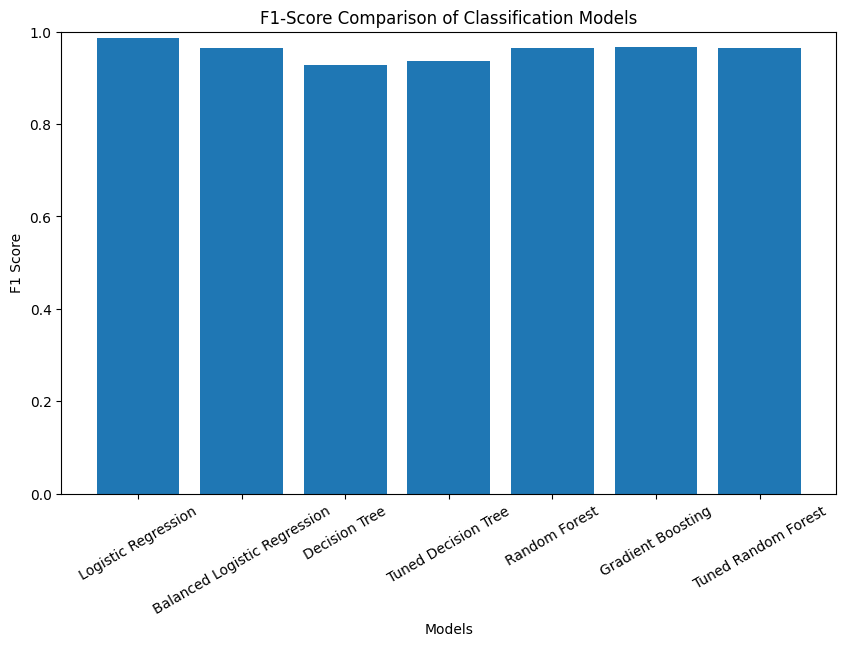

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("F1-Score Comparison of Classification Models")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

## Best Model Selection

In [37]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object


## Model Comparison

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Tuned Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, weighted_pred),
        dt_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        precision,
        precision_score(y_test, weighted_pred),
        dt_precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        recall_score(y_test, weighted_pred),
        dt_recall,
        tuned_recall
    ],
    "F1 Score": [
        f1,
        f1_score(y_test, weighted_pred),
        dt_f1,
        tuned_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539
2,Decision Tree,0.912281,0.955882,0.902778,0.928571
3,Tuned Decision Tree,0.921053,0.956522,0.916667,0.936170


## Best Model Selection

In [28]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object


## Conclusion

- Multiple classification models were implemented and compared.
- Logistic Regression was used as the baseline classification model.
- Decision Tree was used as a tree-based model.
- Random Forest and Gradient Boosting were implemented as ensemble learning techniques.
- 5-fold cross-validation was used to evaluate model reliability.
- GridSearchCV was used for hyperparameter optimization.
- Random Forest feature importance was analyzed to understand model predictions.
- Accuracy, precision, recall and F1-score were used for model evaluation.
- The final model was selected based on the highest F1-score.
- This task demonstrates an end-to-end machine learning workflow from data preprocessing to model comparison and optimization.